## Carregando os dados com a auxilio do pandas

In [80]:
# [1] Primeiro deve rodar essa parte de codigo para o arquivo data.csv seja lido
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_csv("../data/raw/data.csv")

# Remover colunas indesejadas
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Visualizar primeiras linhas
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Esse grafico mostra a quantidade total de cancer maligno e de cancer benigno em relação ao total de pessoas.

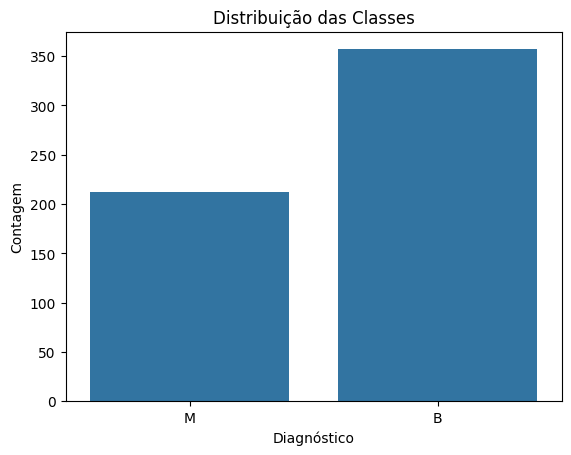

In [66]:
# [2] Gráfico em barras para mostrar a distribuição das classes (Maligno vs Benigno)
sns.countplot(x="diagnosis", data=df)
plt.title("Distribuição das Classes")
plt.xlabel("Diagnóstico")
plt.ylabel("Contagem")
plt.show()

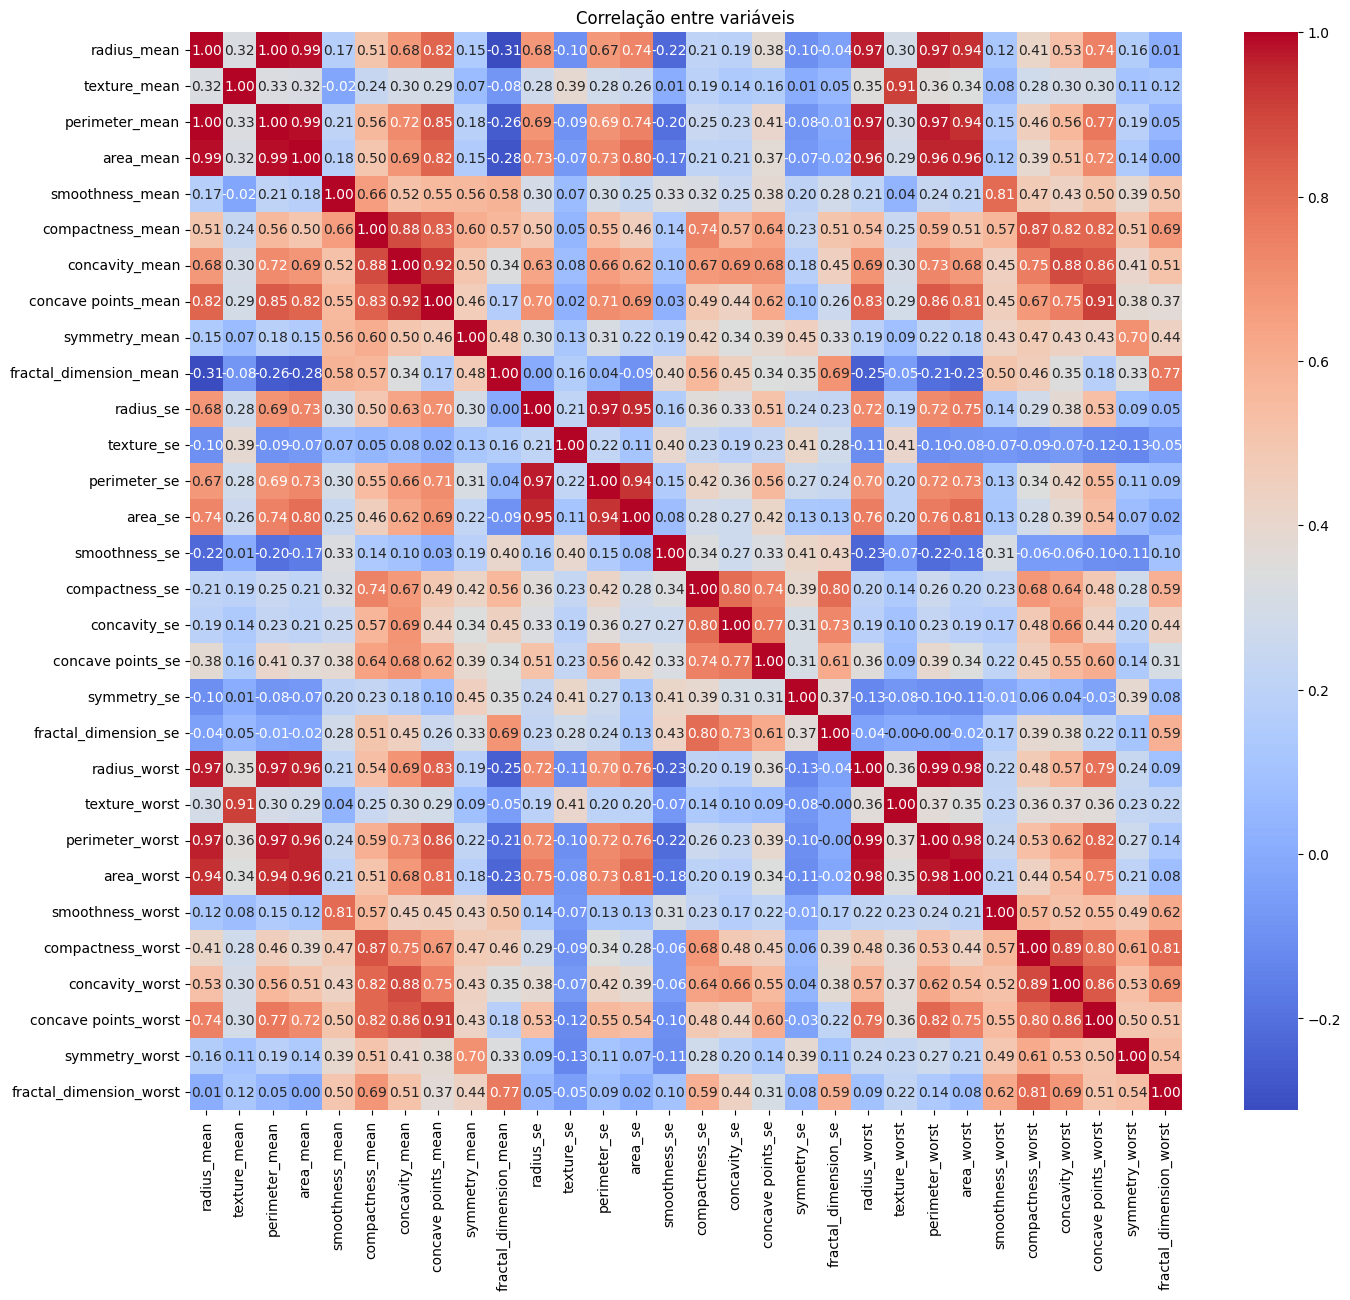

In [67]:
# [3] Heatmap de correlação entre as variáveis numéricas
import numpy as np

plt.figure(figsize=(16, 14))

corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Correlação entre variáveis")
plt.show()

In [68]:
# [4] Mostra quais variáveis mais influenciam o diagnóstico.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

corr_target = df.corr()['diagnosis'].sort_values(ascending=False)

print(corr_target)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

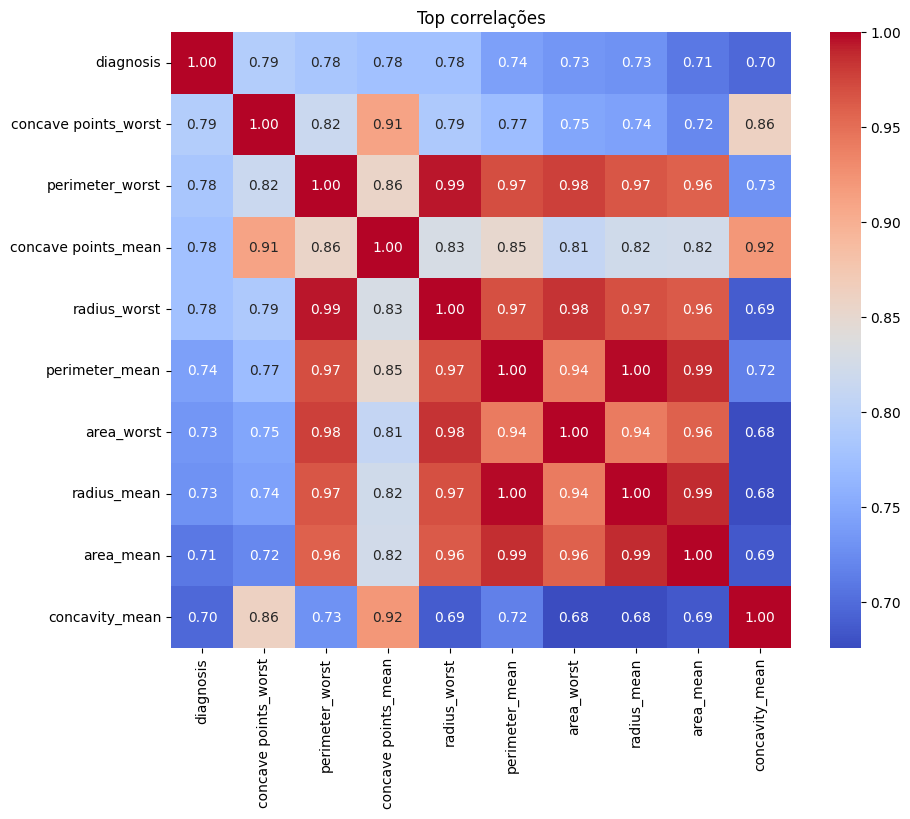

In [69]:
# [5] Heatmap de correlação entre as variáveis numéricas mais importantes
top_features = corr_target.abs().sort_values(ascending=False).head(10).index

corr_top = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top correlações")
plt.show()

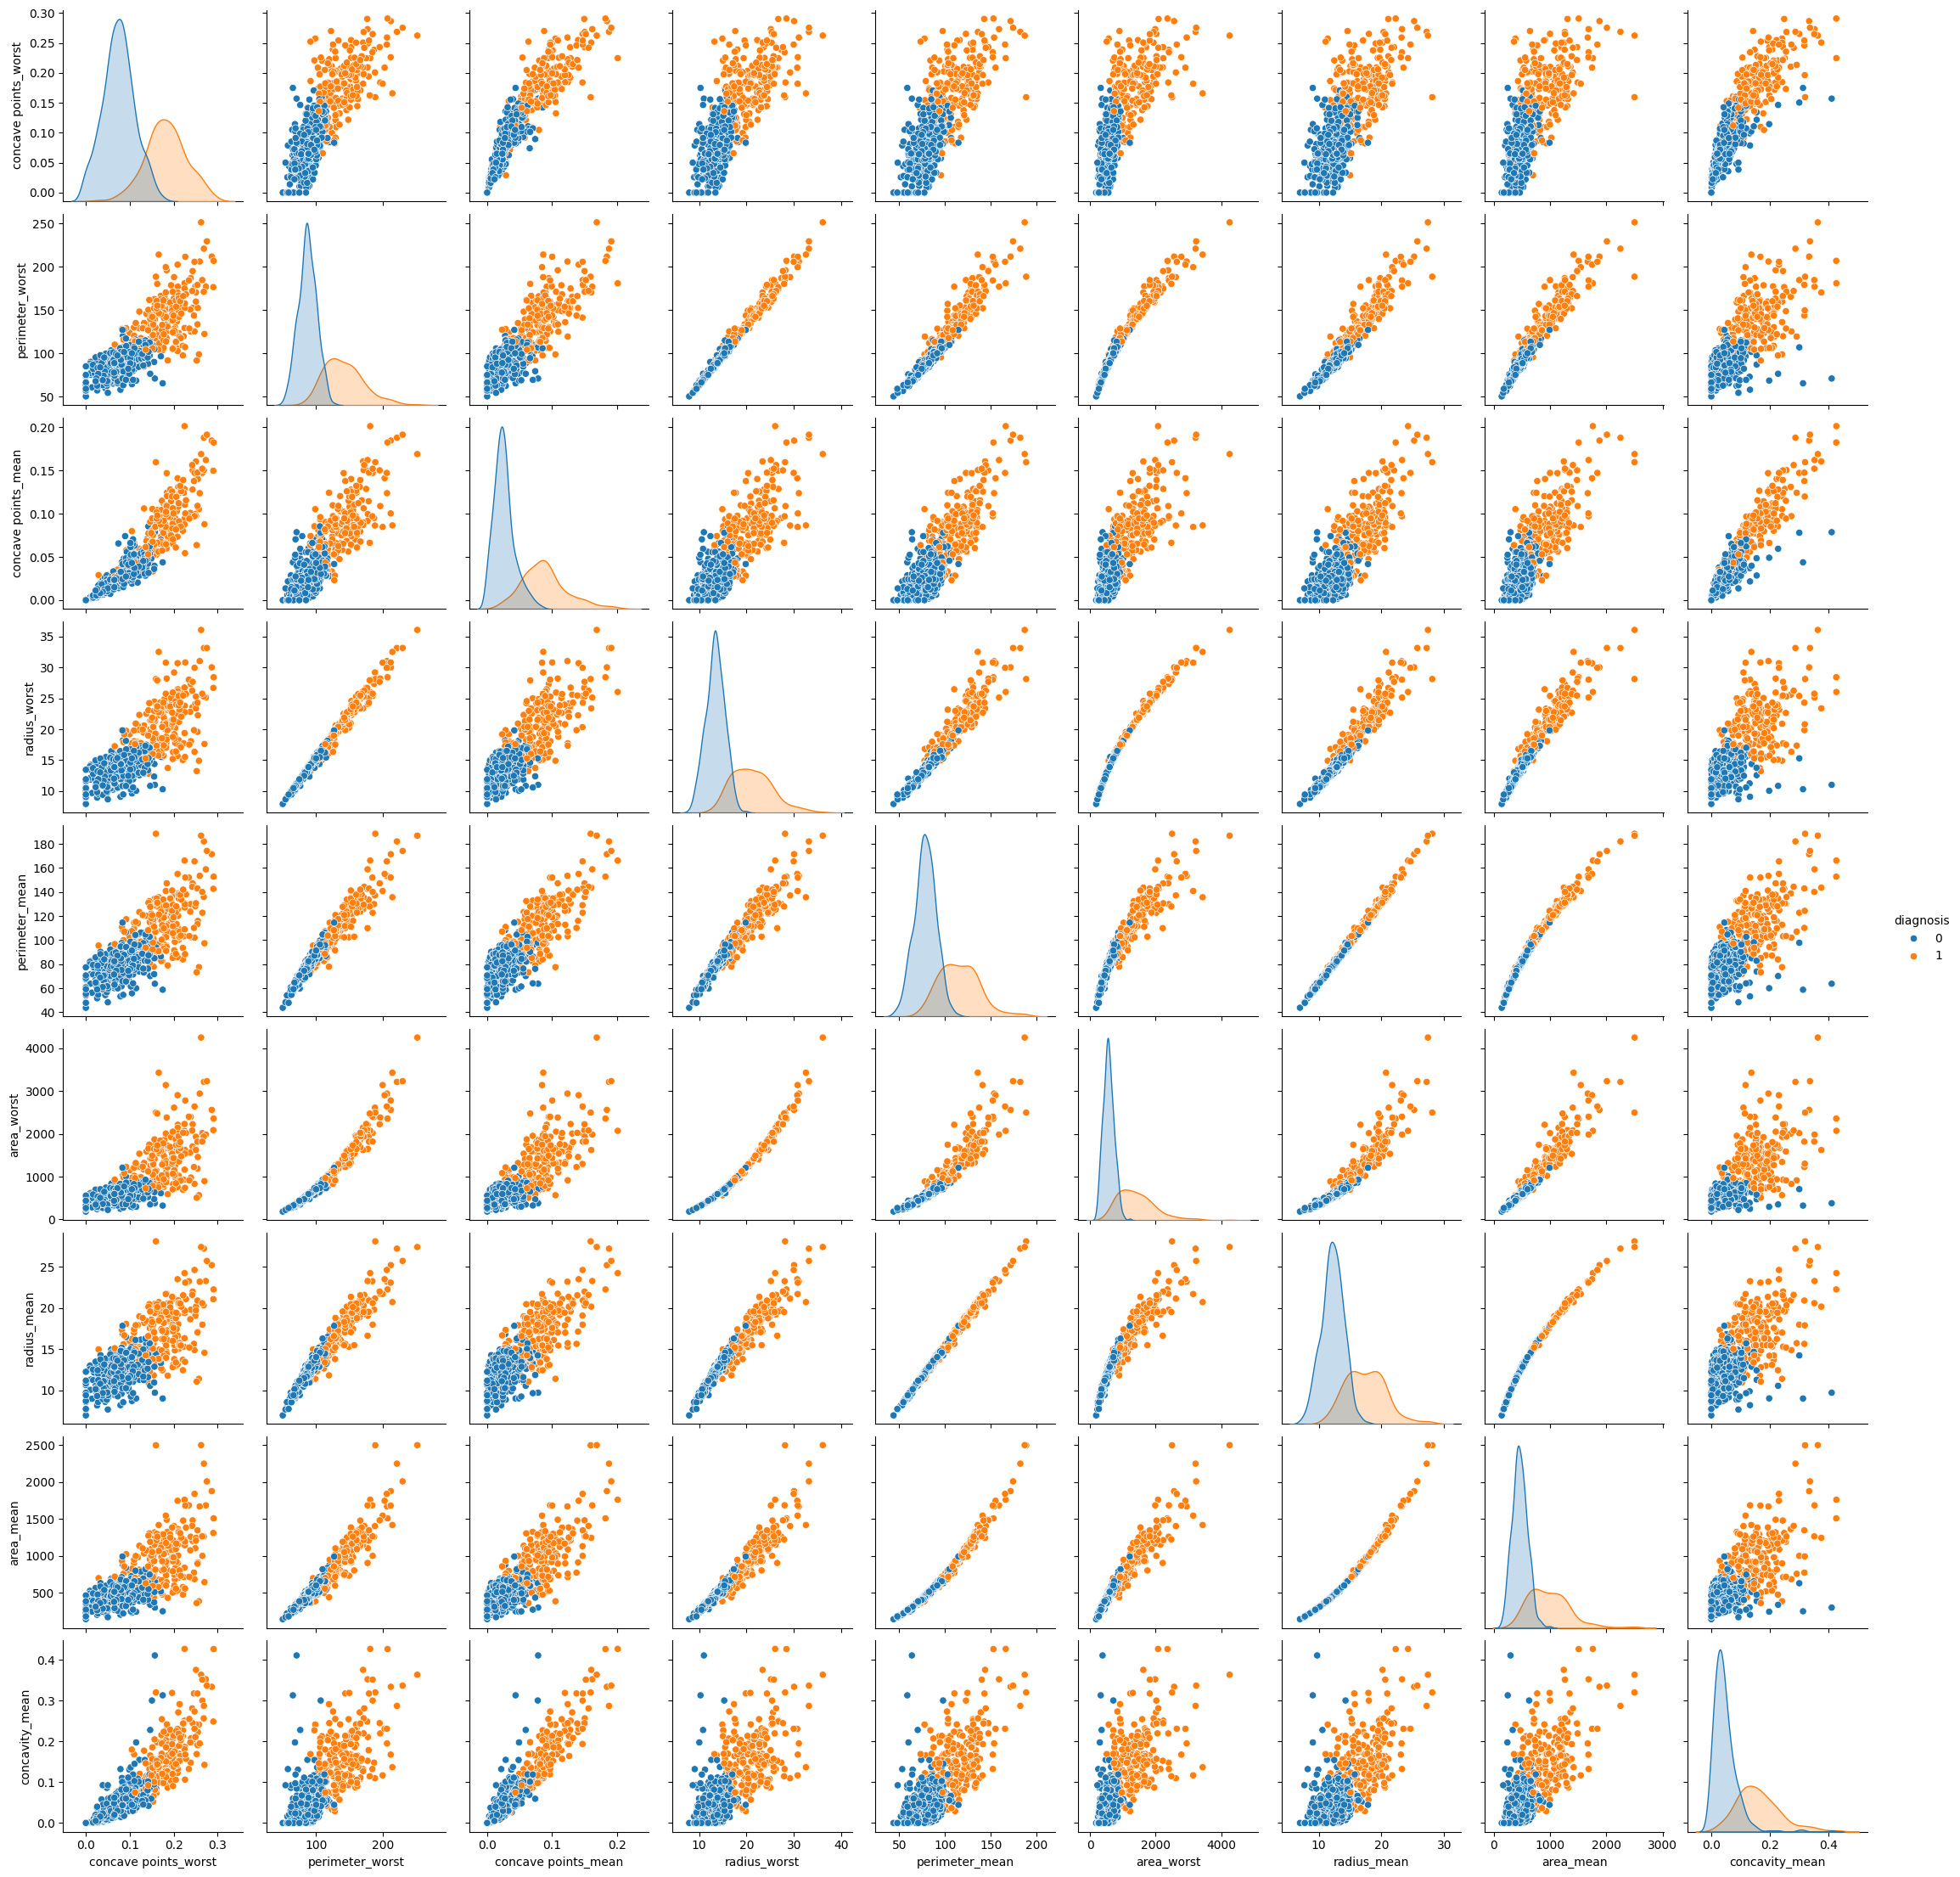

In [70]:
# [6] Pairplot (relações visuais entre variáveis)
sns.pairplot(df[top_features], hue='diagnosis')
plt.show()

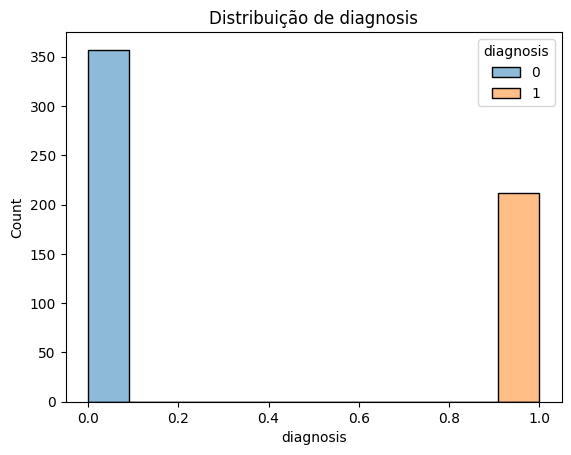

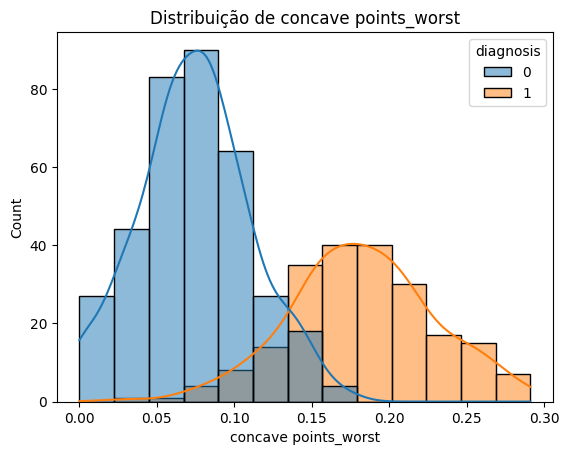

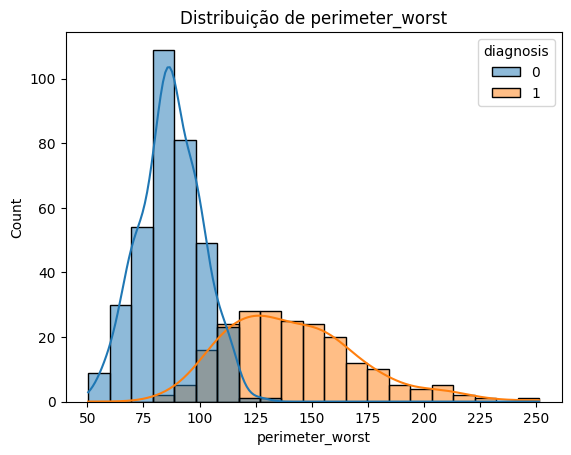

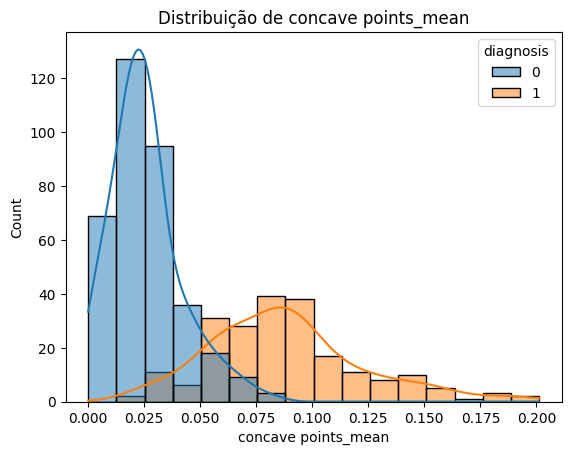

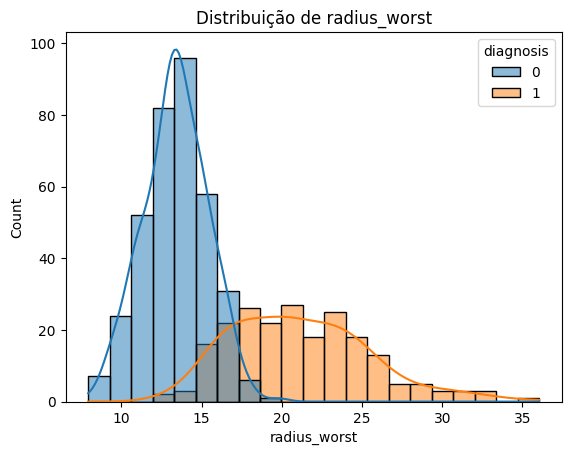

In [71]:
# [7] Distribuição por classe, mostra como as variáveis se distribuem para cada classe (Maligno vs Benigno)
for col in top_features[:5]:
    plt.figure()
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

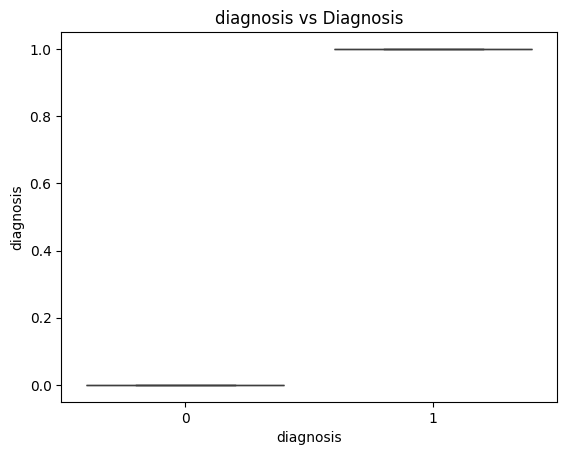

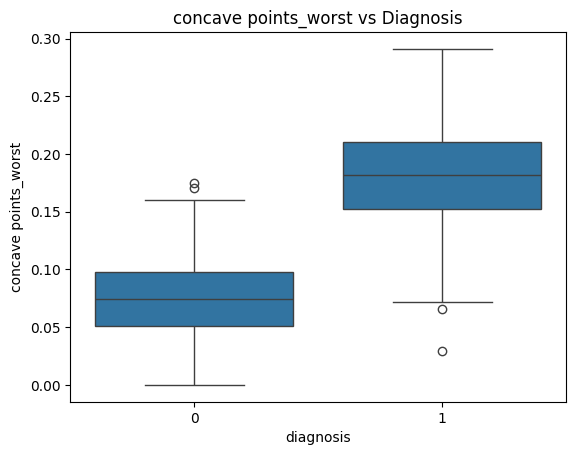

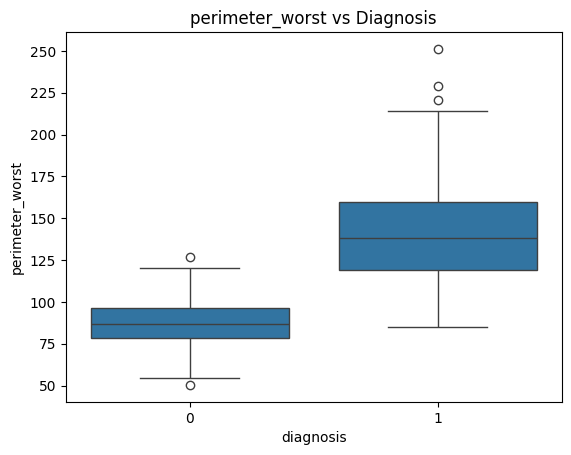

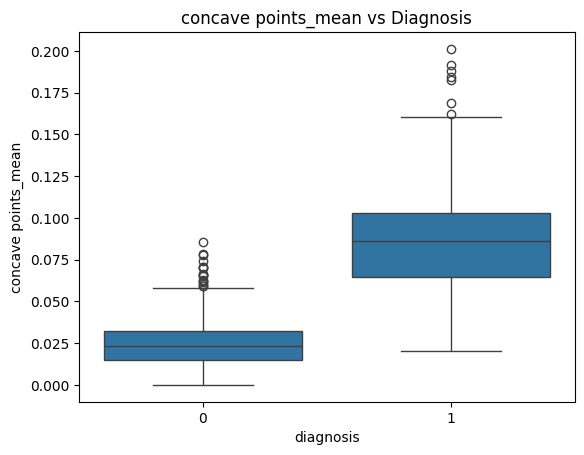

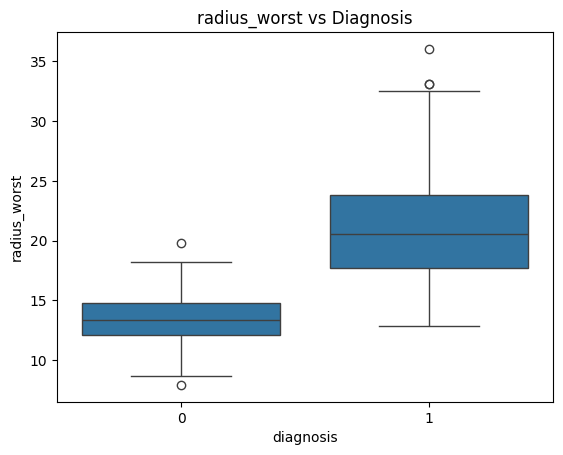

In [72]:
# [8] Boxplot por classe, mostra a distribuição das variáveis para cada classe (Maligno vs Benigno)
for col in top_features[:5]:
    plt.figure()
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

In [73]:
# [9] Detectar multicolinearidade entre as variáveis numéricas, mostrando quais variáveis estão altamente correlacionadas entre si.
import numpy as np
corr = df.select_dtypes(include=[np.number]).corr()
high_corr = corr.abs() > 0.9

print(high_corr.sum().sort_values(ascending=False))

radius_mean                6
area_mean                  6
perimeter_mean             6
perimeter_worst            6
area_worst                 6
radius_worst               6
radius_se                  3
area_se                    3
perimeter_se               3
concave points_mean        3
concavity_mean             2
texture_worst              2
texture_mean               2
concave points_worst       2
diagnosis                  1
texture_se                 1
fractal_dimension_mean     1
symmetry_mean              1
compactness_mean           1
smoothness_mean            1
concave points_se          1
smoothness_se              1
compactness_se             1
symmetry_se                1
fractal_dimension_se       1
concavity_se               1
smoothness_worst           1
compactness_worst          1
concavity_worst            1
symmetry_worst             1
fractal_dimension_worst    1
dtype: int64


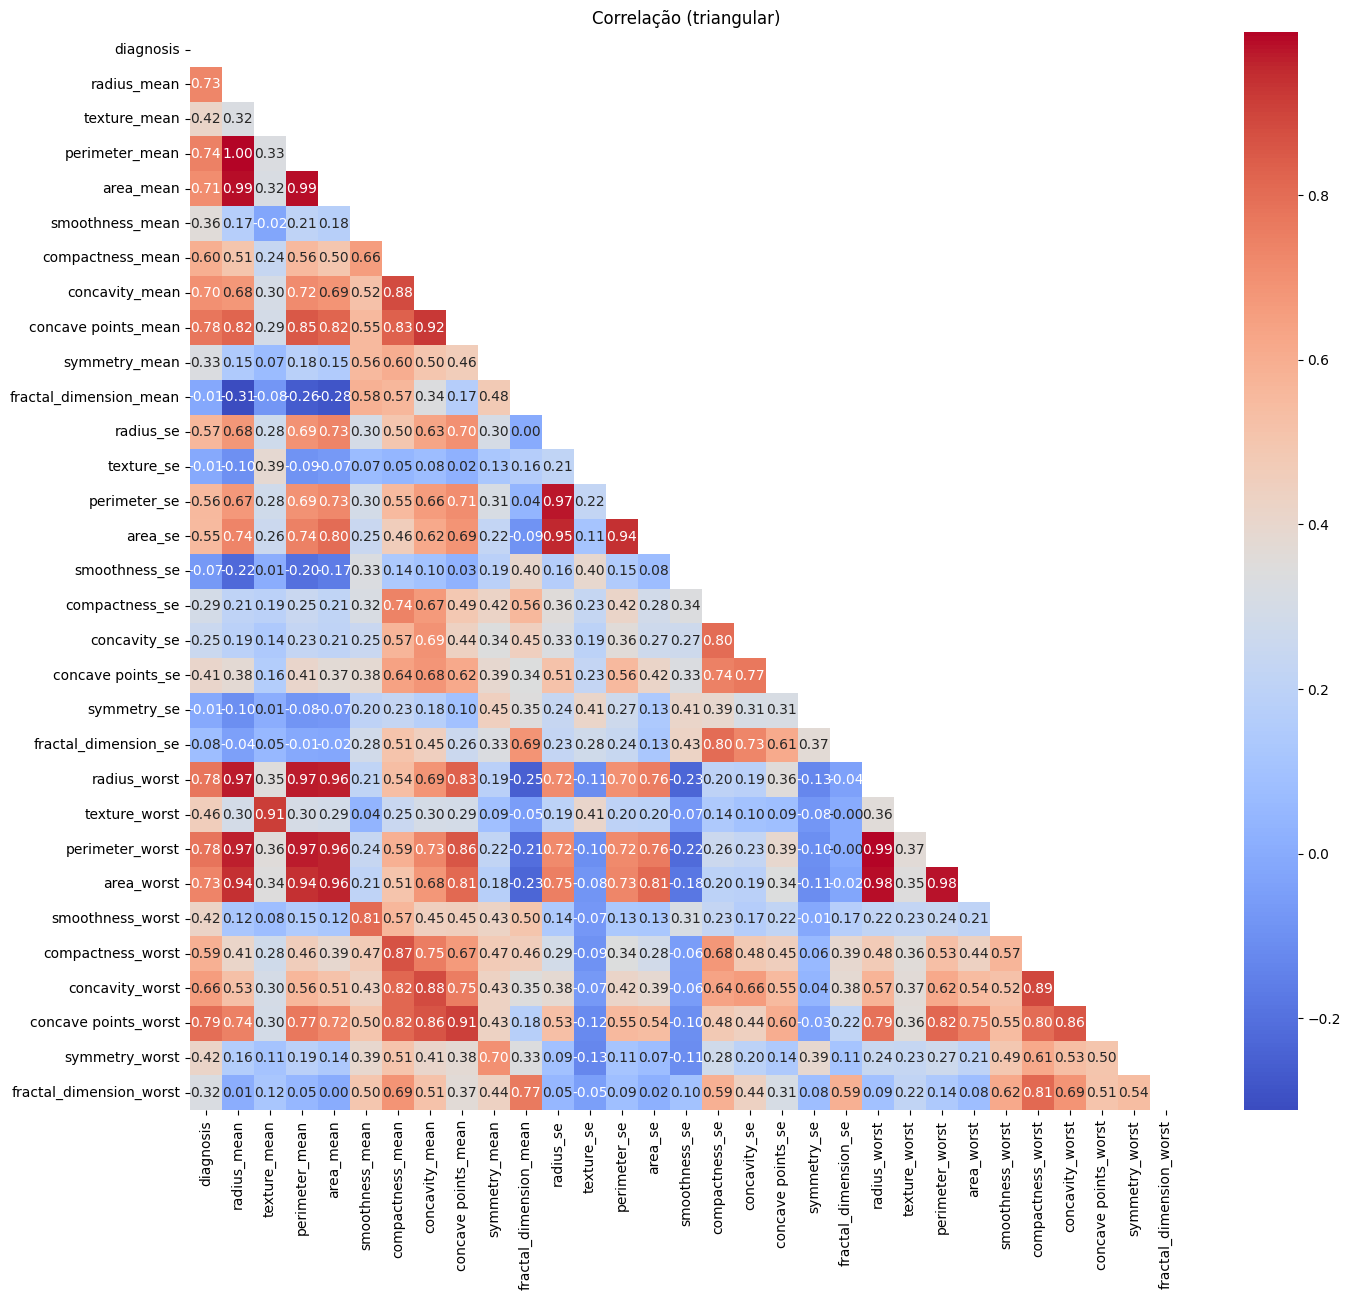

In [74]:
# [10] Heatmap triangular para mostrar apenas a parte superior da matriz de correlação, evitando redundância.
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação (triangular)")
plt.show()

In [81]:
# Ranking das variáveis mais importantes para o diagnóstico, mostrando as 10 mais influentes.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

corr_target = df.corr()['diagnosis'].abs().sort_values(ascending=False)

print(corr_target[1:10])

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64
